# Exploratory Data Analysis - EDA 0202226

## Librerias

In [1]:
import pymysql
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

## Cargar datos

In [3]:
data_path = r"../Data/Bronze_BANK_marketing_020226.csv"

In [7]:
# Cargar el dataset con separador y encoding correctos
try:
    df = pd.read_csv(
        data_path,
        sep=",",
        encoding="utf-8"
    )
    print("CSV cargado correctamente")
    print(df.head())
except Exception as e:
     print("Error al cargar el CSV:", e)

CSV cargado correctamente
   id   age         job  marital  education default  balance housing loan  \
0   1  59.0      admin.  married  secondary      no     2343     yes   no   
1   2  56.0      admin.  married  secondary      no       45      no   no   
2   3  41.0  technician  married  secondary      no     1270     yes   no   
3   4  55.0    services  married  secondary      no     2476     yes   no   
4   5  54.0      admin.  married   tertiary      no      184      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome deposit  
0  unknown    5   may      1042         1     -1         0  unknown     yes  
1  unknown    5   may      1467         1     -1         0  unknown     yes  
2  unknown    5   may      1389         1     -1         0  unknown     yes  
3  unknown    5   may       579         1     -1         0  unknown     yes  
4  unknown    5   may       673         2     -1         0  unknown     yes  


## Resumen 

### Calidad de los Datos
El análisis inicial muestra que el dataset presenta una estructura consistente, conformado por 11.162 registros (+164 registros más que la semana pasada) y 18 columnas con variables numéricas y categóricas correctamente definidas. No se detectan valores duplicados (0 registros) y valores nulos en __age__ (10 registros), __marital__ (5 registros) y __education__ (7 registros) los cuales deberán considerarse en etapas posteriores del análisis.

### Estadísticas Descriptivas
Las estadísticas descriptivas evidencian una alta variabilidad en algunas variables numéricas, especialmente en aquellas relacionadas con el __balance__ y la __duración__, lo que sugiere la posible presencia de valores extremos en el conjunto de datos. 

### Limitaciones Iniciales
En las variables categóricas se observa la presencia de valores __"unknown"__ en campos como *poutcome* (8.326 unknown, +142 respecto la semana pasada), __contact* (2.346,+47 respecto a la semana pasada), __education__ (496, +2 respecto a la semana pasada) y __job__ (70, se mantiene igual que la semana pasada). Y también podemos observar que la columna __pdays__ cuenta con (8.324, +142 en comparación a la semana pasada) registros en (-1) que suele indicar que el cliente no ha sido contactado. Estos datos representan una modificación en los valores iniciales y deberán ser tratados o evaluados según los objetivos del análisis.

### Data Cleaning
Como próximos pasos, en el proceso de data cleaning se deberá:
 - Tratamiento de valores faltantes: age (10), marital (5) y education(7)
 - Eliminación o corrección de duplicados: No aplica
 - Validación y corrección de valores atípicos: No se aprecian
 - Estandarización de formatos: Eliminación de valores negativos en pdays
 - Corrección de tipos de datos: se deben transformar age (int), y default, housing, loan y deposit a boolean  

## 1. DATA QUALITY - Resúmenes estadísticos de las variables

In [9]:
# Dimensiones del dataset
df.shape

(11162, 18)

In [10]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [11]:
# Info general del dataset y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         11162 non-null  int64  
 1   age        11152 non-null  float64
 2   job        11162 non-null  object 
 3   marital    11157 non-null  object 
 4   education  11155 non-null  object 
 5   default    11162 non-null  object 
 6   balance    11162 non-null  int64  
 7   housing    11162 non-null  object 
 8   loan       11162 non-null  object 
 9   contact    11162 non-null  object 
 10  day        11162 non-null  int64  
 11  month      11162 non-null  object 
 12  duration   11162 non-null  int64  
 13  campaign   11162 non-null  int64  
 14  pdays      11162 non-null  int64  
 15  previous   11162 non-null  int64  
 16  poutcome   11162 non-null  object 
 17  deposit    11162 non-null  object 
dtypes: float64(1), int64(7), object(10)
memory usage: 1.5+ MB


### 1.1. Duplicados

In [12]:
# Info de filas duplicadas
df.duplicated().sum()

np.int64(0)

### 1.2. Valores nulos

In [13]:
df.isnull().sum()

id            0
age          10
job           0
marital       5
education     7
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### 1.3 Resumen de variables númericas

In [16]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

global_numeric_stats = df[numeric_cols].describe().T

global_numeric_stats

,count,mean,std,min,25%,50%,75%,max
age,11152.0,41.235384,11.914934,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [31]:
df['pdays'].value_counts().head(100)

pdays
-1      8324
 92      106
 182      89
 91       84
 181      81
        ... 
 164       8
 266       8
 205       8
 323       8
 199       8
Name: count, Length: 100, dtype: int64

### 1.4 Resumen de variables categóricas

In [17]:
def resumen_variables_categoricas(dataframe):
    """
    Genera un resumen de variables categóricas:
    - número de categorías
    - valor más frecuente
    - porcentaje del valor más frecuente
    """
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    resumen_categorico = []

    total_rows = len(dataframe)

    for column in categorical_columns:
        value_counts = dataframe[column].value_counts(dropna=False)

        most_frequent_value = value_counts.index[0]
        most_frequent_percentage = (value_counts.iloc[0] / total_rows) * 100
        unique_categories = dataframe[column].nunique(dropna=False)

        resumen_categorico.append({
            "variable": column,
            "unique_categories": unique_categories,
            "most_frequent_value": most_frequent_value,
            "most_frequent_percentage": round(most_frequent_percentage, 2)
        })

    resumen_categorico_df = pd.DataFrame(resumen_categorico)

    return resumen_categorico_df

In [18]:
# Aplico resumen_variables_categoricas a df
categorical_summary = resumen_variables_categoricas(df)

categorical_summary

,variable,unique_categories,most_frequent_value,most_frequent_percentage
0,job,12,management,22.99
1,marital,4,married,56.88
2,education,5,secondary,49.04
3,default,2,no,98.49
4,housing,2,no,52.69
5,loan,2,no,86.92
6,contact,3,cellular,72.05
7,month,12,may,25.30
8,poutcome,4,unknown,74.59
9,deposit,2,no,52.62


## 2. LIMITATIONS - Valores nulos y unkwown

### 2.1 Missing data

In [19]:
def resumen_missing_data(dataframe):
    """
    Genera un resumen de valores missing por columna
    """
    # Conteo de valores nulos por columna
    missing_count = dataframe.isna().sum()

    # Porcentaje de valores nulos
    missing_percentage = ((missing_count / len(dataframe)) * 100).round(2)

    # Crear DataFrame resumen (DataFrame con D mayúscula)
    missing_summary_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values(
        by="missing_percentage",
        ascending=False
    )

    return missing_summary_df

In [20]:
# aplicar resumen_missing_data dataset 
missing_summary = resumen_missing_data(df)

missing_summary

,missing_count,missing_percentage
age,10,0.09
education,7,0.06
marital,5,0.04
id,0,0.00
job,0,0.00
default,0,0.00
balance,0,0.00
housing,0,0.00
loan,0,0.00
contact,0,0.00


### 2.2 Valores unknown

In [21]:
def resumen_unknown_values(dataframe):
    """
    Cuenta valores 'unknown' por columna
    """
    unknown_count = (dataframe == "unknown").sum()

    unknown_summary_df = (
        unknown_count[unknown_count > 0]
        .to_frame(name="unknown_count")
        .sort_values(by="unknown_count", ascending=False)
    )

    return unknown_summary_df

In [22]:
# aplicar resumen_unknown_values a df
unknown_summary = resumen_unknown_values(df)
unknown_summary

,unknown_count
poutcome,8326
contact,2346
education,496
job,70


## 3. DISTRIBUTIONS - Gráficos de distribución de datos

### 3.1 Visualización de datos númericos

In [23]:
def auto_visualize_dataframe_histplot(df):    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")

            median = df[column].median()
            plt.axvline(median, color="green", linestyle="-", label=f"Median: {median:.1f}")

            mean = df[column].mean()
            plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f}")
            
            plt.show()

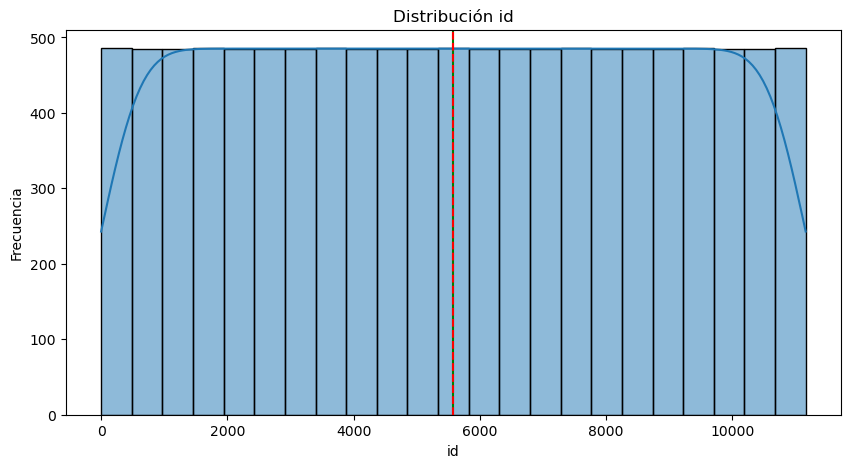

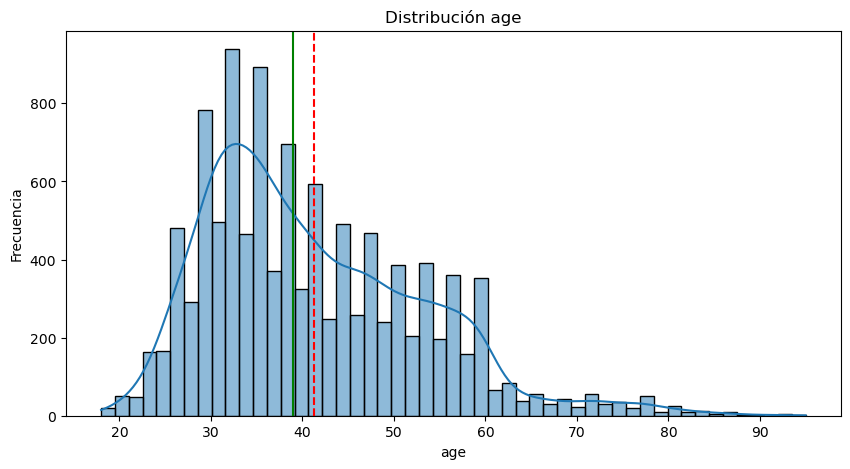

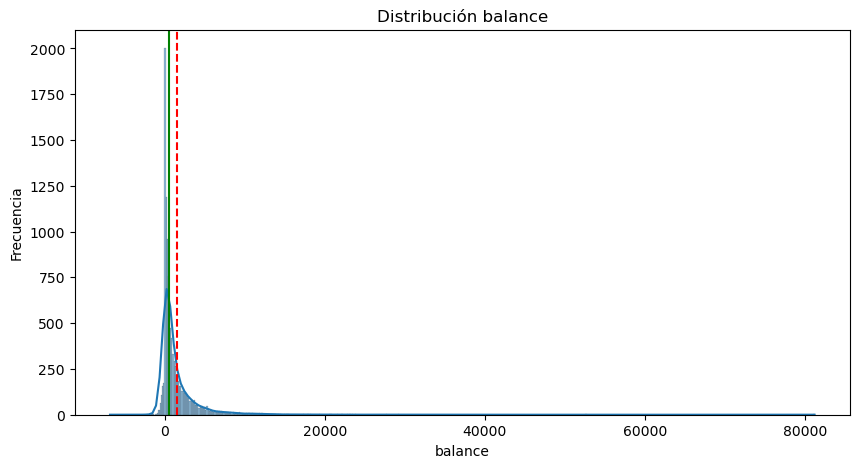

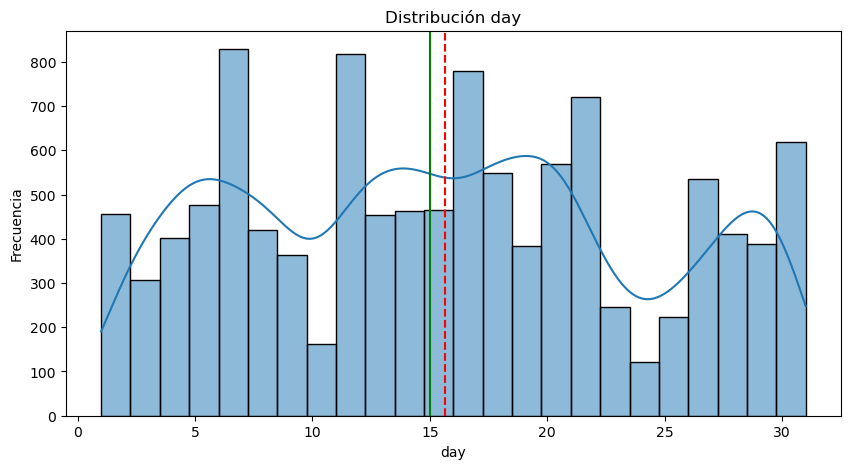

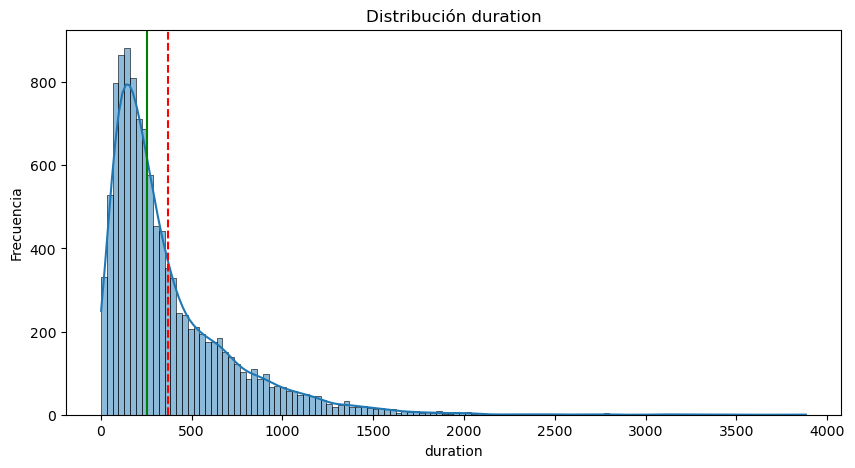

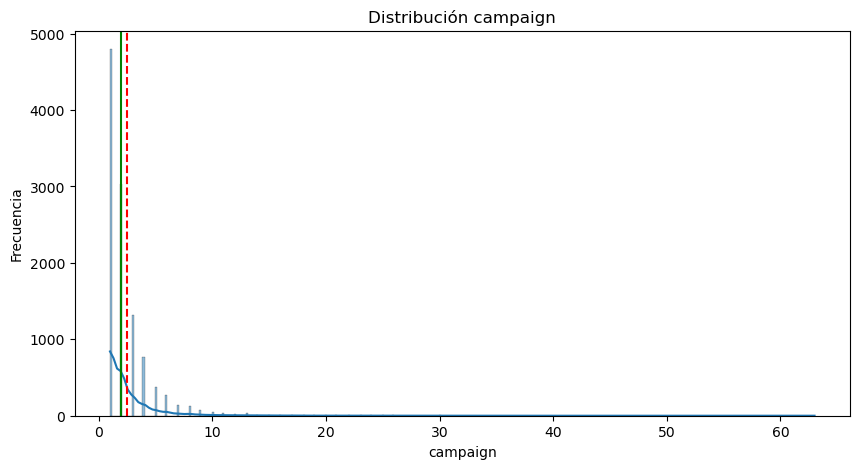

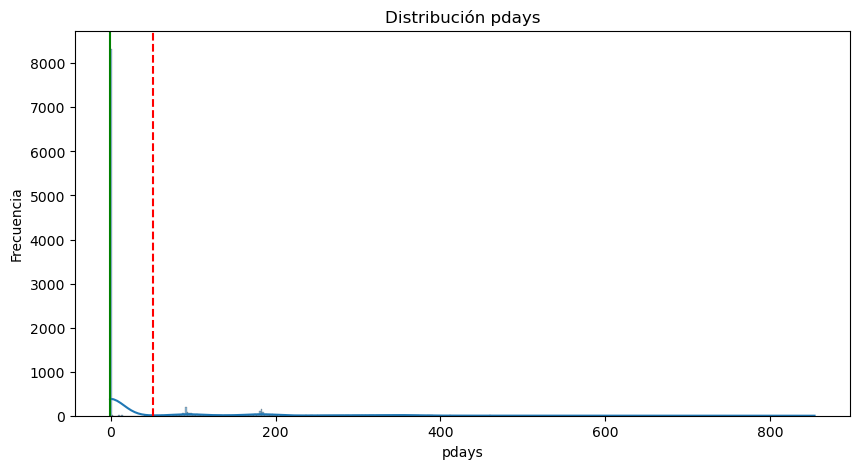

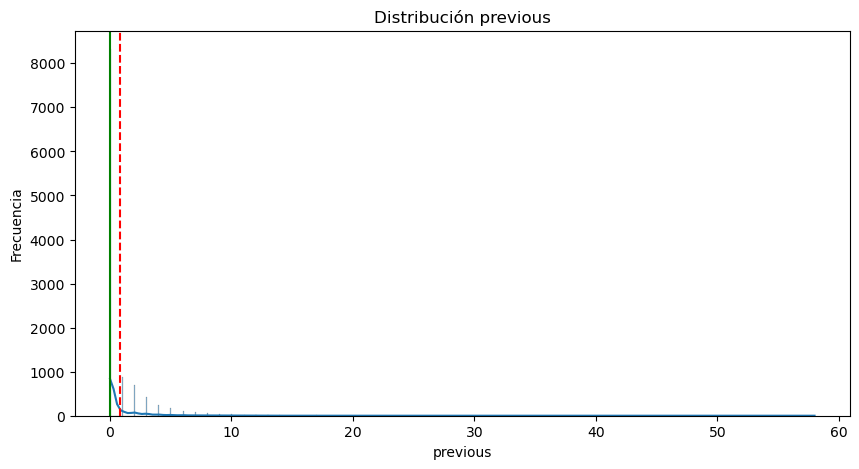

In [24]:
histogramas = auto_visualize_dataframe_histplot(df) 

histogramas

### 3.2. Visualización de variables categóricas

In [25]:
def plot_categorical_distribution(df, exclude=None):
    if exclude is None:
        exclude = []
    
    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in exclude]

    for col in cat_cols:
        percentages = df[col].value_counts(normalize=True) * 100

        plt.figure()
        plt.bar(percentages.index.astype(str), percentages.values)
        plt.title(f'Distribución porcentual de {col}')
        plt.ylabel('Porcentaje (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.show()

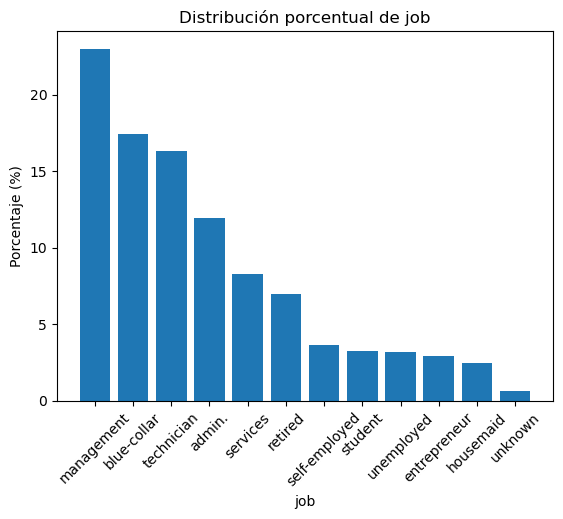

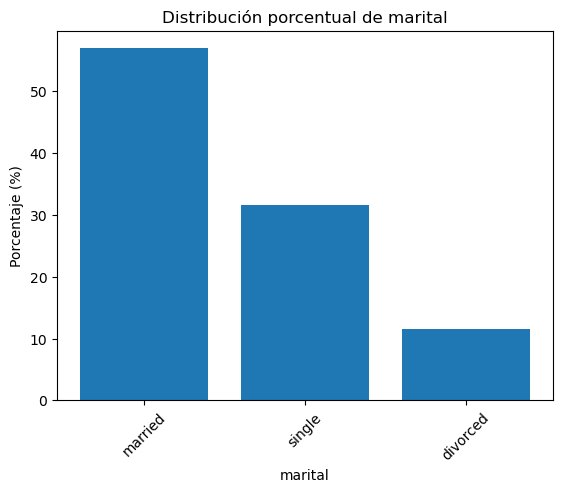

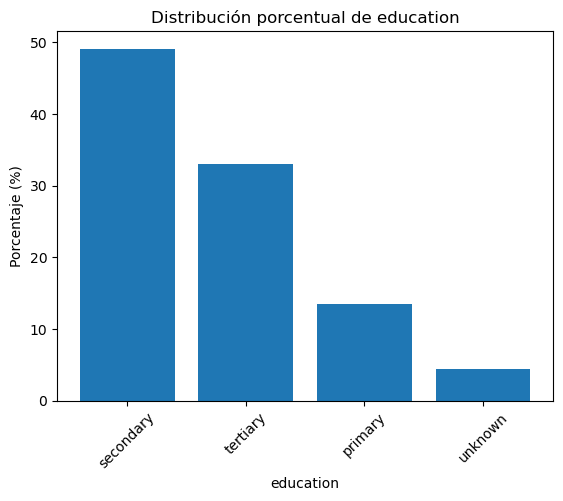

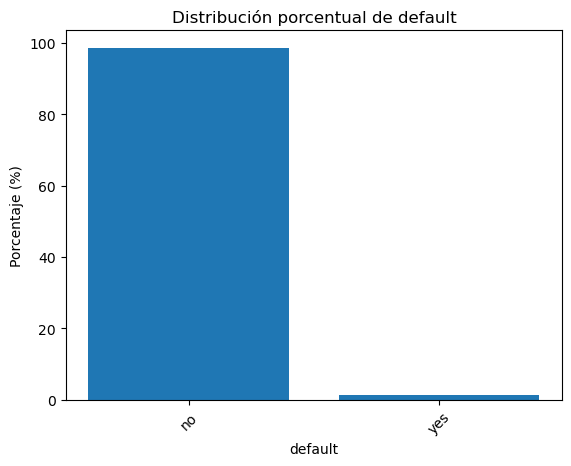

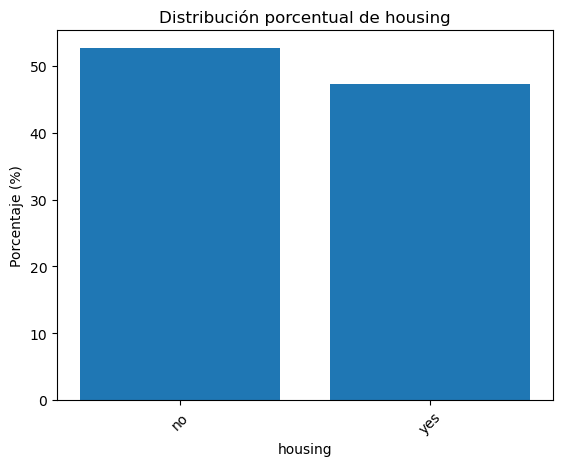

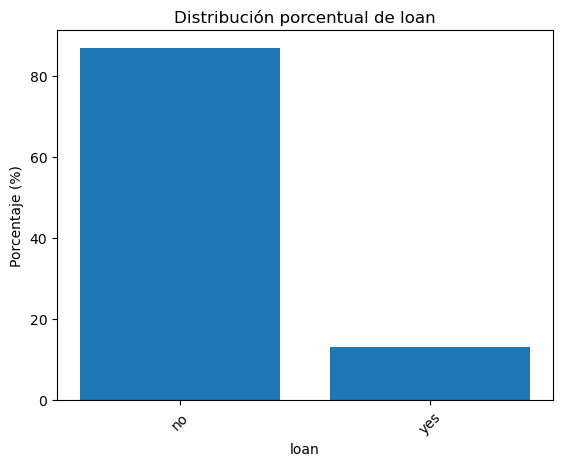

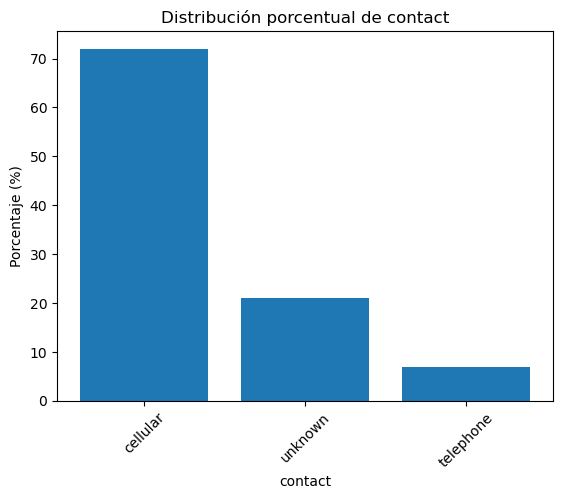

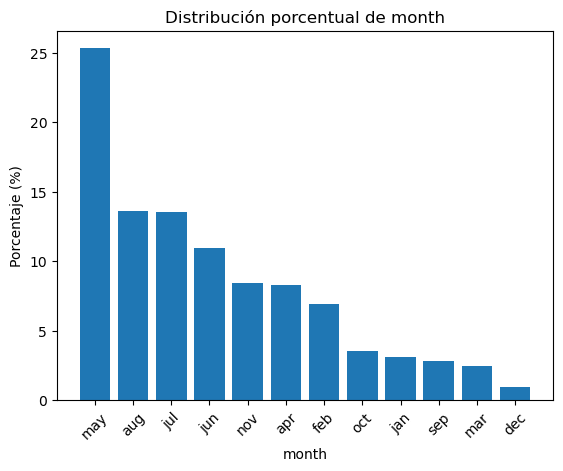

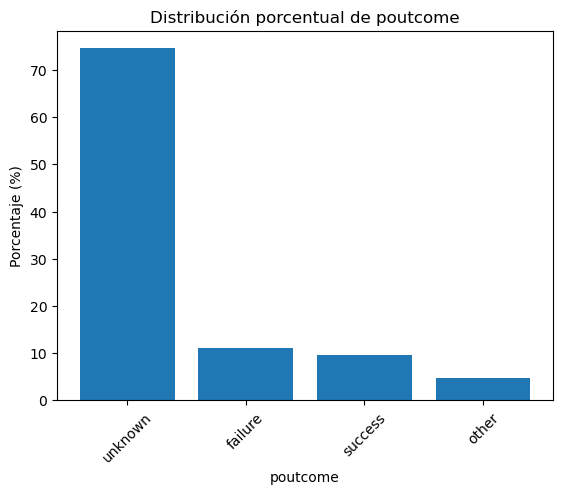

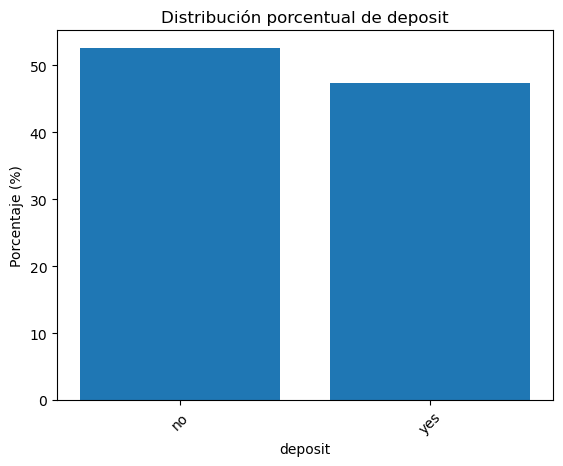

In [26]:
plot_categorical_distribution(df)

### 3.3. Visualización de variable objetivo - Deposit

In [28]:
# Distribución deposit
df['deposit'].value_counts(normalize=True) * 100

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

In [29]:
# Relación entre variables y deposit

def plot_categorical_vs_target(df, target, exclude=None, max_categories=10):
    if exclude is None:
        exclude = []

    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in exclude]

    for col in cat_cols:
        if df[col].nunique() > max_categories:
            continue

        ct = pd.crosstab(df[col], df[target], normalize='index') * 100

        ct.plot(kind='bar')
        plt.title(f'{col} vs {target} (%)')
        plt.ylabel('Porcentaje (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45)
        plt.legend(title=target)
        plt.show()

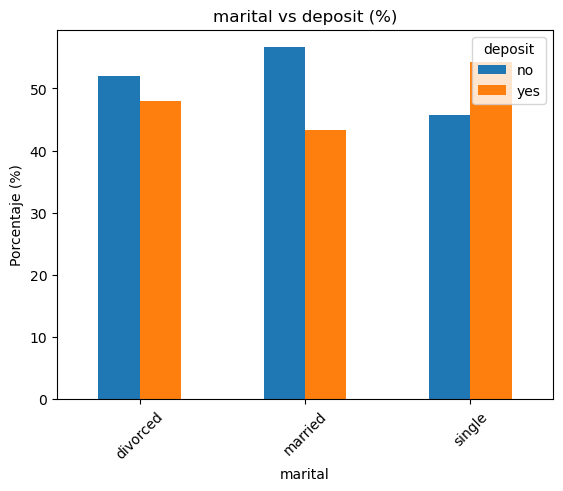

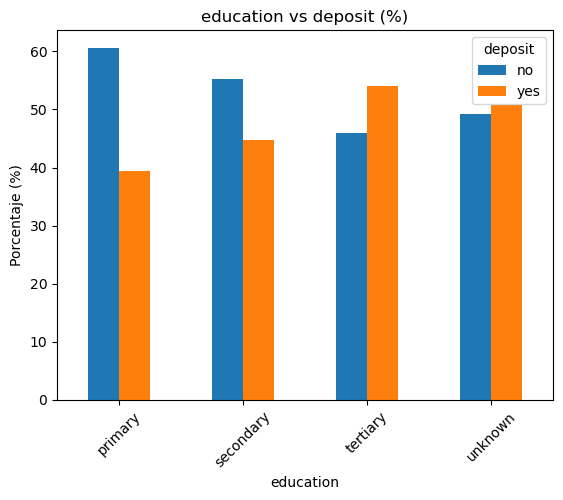

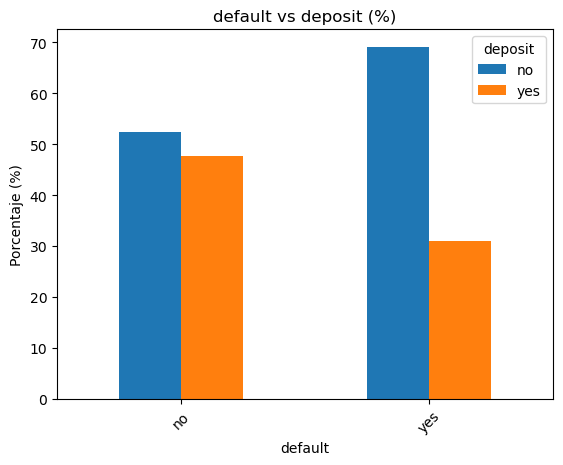

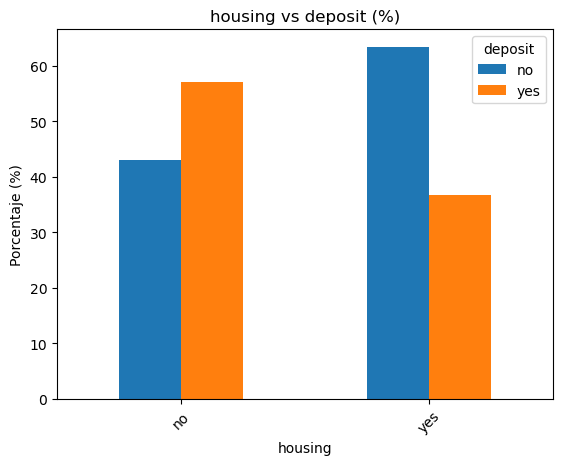

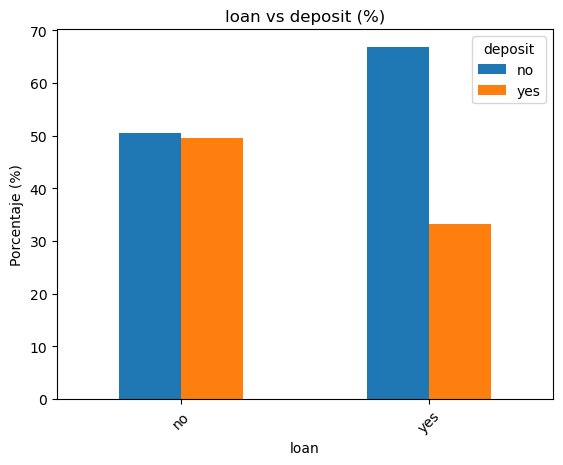

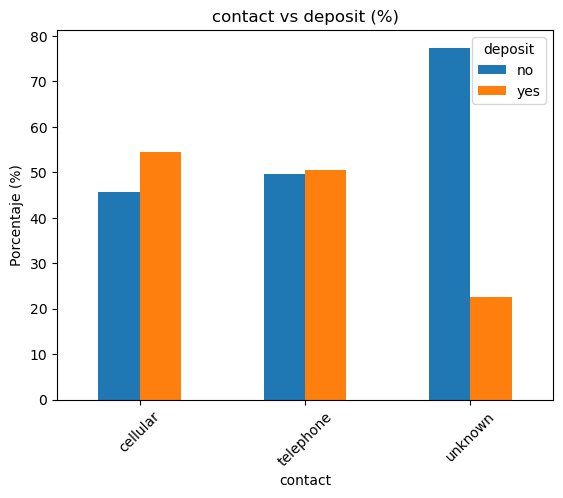

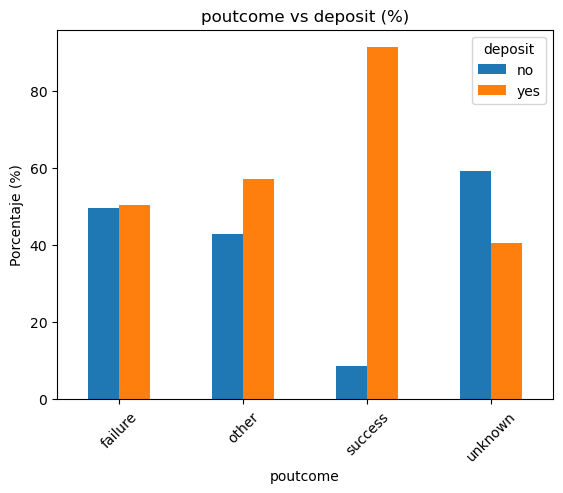

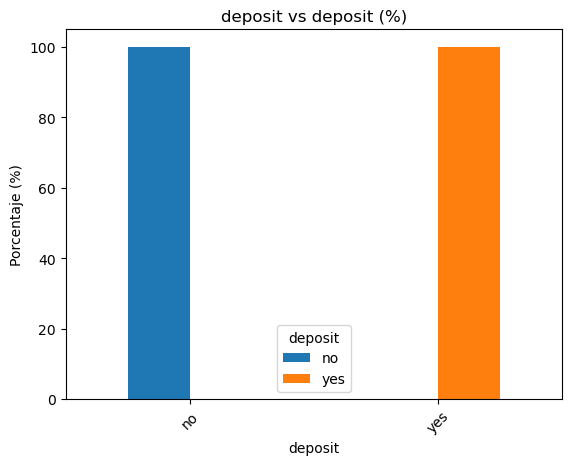

In [30]:
plot_categorical_vs_target(df, target='deposit')
